## Aim

In this code, I do a few checks before writing the actual programs:

- I want to read a network and then save it for later use
- See if it is possible once I have the bigger network and when I have save it to extract networks bases on the wards. This avoids that one has to hit the Overpass server multiple times in case one would download the network for each ward seperately (369 wards in total).

In this code, I only look at the driveable roads 

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
print(f'The version of geopandas is {gpd.__version__}')
print(f'The version of osmnx is {ox.__version__}')

The version of geopandas is 1.1.2
The version of osmnx is 2.0.7


## Reading and saving the Bangalore network

In [3]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [4]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [5]:
## Dissolved wards
df_inpath_dissolved = PROCESSED_DIR / "chennai_dissolved.shp"

In [6]:
df = gpd.read_file(df_inpath)
df.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


In [7]:
print(f'The shape of the Geopandas dataframe is {df.shape}.')
print(f'There are {df.shape[0]} wards in the dataframe.')
print(f'The different columns are {df.columns}')

The shape of the Geopandas dataframe is (200, 4).
There are 200 wards in the dataframe.
The different columns are Index(['Name', 'zone_id', 'zone_name', 'geometry'], dtype='object')


Although the wards data are cleaned up in QGIS and Mapshaper, we check once more for the validity using Geopandas:

In [8]:
df.geometry.is_valid.value_counts()

True    200
Name: count, dtype: int64

In [9]:
print(f'There are {df.shape[0]} wards in Chennai.')

There are 200 wards in Chennai.


## Extracting the road network data

<Axes: >

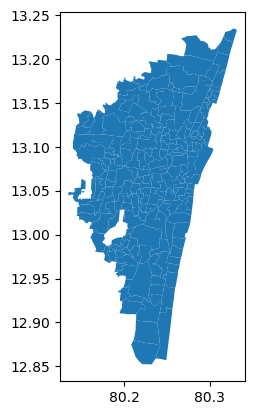

In [10]:
df.plot()

In [11]:
chennai_dissolved = gpd.read_file(df_inpath_dissolved)

Please note that we earlier have closed the "hole". Alternatively we could have also used the dissolved file with the hole. However, we used the "closed" one since it will not matter for the computations later on at the ward level.

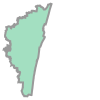

In [12]:
geometry_chennai = chennai_dissolved["geometry"].iloc[0]
geometry_chennai

<Axes: >

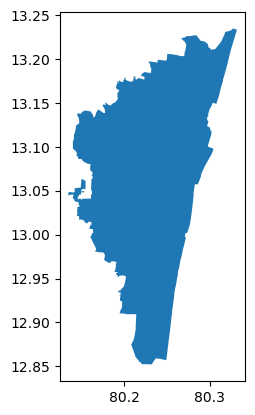

In [13]:
chennai_dissolved.plot()

Alternatively, you can also use the street network with the "hole" filled up:

This downloads all the streets. More specifically this consists of:
- 'all' - all OSM streets and paths, including private-access ones (this is the default network type unless you specify a different one)
- 'all_public' - all non-private OSM streets and paths
- 'bike' - all streets and paths that cyclists can use
- 'drive' - drivable public streets (but not service roads)
- 'drive_service' - drivable streets, including service roads
- 'walk' - all streets and paths that pedestrians can use

In [15]:
G = ox.graph_from_polygon(
    geometry_chennai,
    simplify=True,
    network_type = 'drive')

In [15]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [22]:
## Save the network for later use as a) graph and b) geopandas dataframe
## https://github.com/gboeing/osmnx-examples/blob/main/notebooks/
## 05-save-load-networks.ipynb
path_gpkg_chennai = DATA_DIR / "gpkg_chennai" / "chennai_gpkg_drive.gpkg"

ox.io.save_graph_geopackage(G, filepath=path_gpkg_chennai)

A small part of this network will be visualised below. Alternatively, you can upload the file in QGIS. You should see 2 layers. One for the nodes and another one for the edges.

In [16]:
# Save as a network
path_graphml_bang = DATA_DIR / "graphml_chennai" / "chennai_graphml_drive.graphml"
ox.io.save_graphml(G, filepath = path_graphml_bang)

Loading this again (we will  not do that here right now but you can do that at any point in your code and uncomment this line) but you can load the Geopackage like any other loading any regular .gpkg file in Python using Geopandas. The Geopandas file contains two layers. It is best to specify which layer to use in order to avoid warnings. 

In [17]:
# gpkg_test_edges = gpd.read_file(path_gpkg_chennai, layer = 'edges')
# gpkg_test_edges.head()

In [18]:
# gpkg_test_edges.columns

In [19]:
#  gpkg_test_nodes = gpd.read_file(path_gpkg_chennai, layer = 'nodes')
# gpkg_test_nodes.head()

## Visualisation

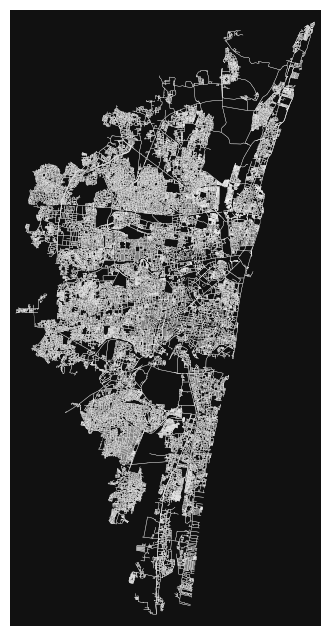

In [23]:
# osmnx built-in plotting
# You can change the basic settings but this here are the default settings
fig, ax = ox.plot_graph(G, node_size=0, edge_color="w", edge_linewidth=0.2)

Convert the graph you loaded in into a Geopandas dataframe. The files that you saved above can also be loaded in otherwise. 

We can convert the graph to a Geopandas dataframe (as this may be easier to work with especially if you want to overlay this with other datasets). 

In [21]:
# nodes, edges = ox.graph_to_gdfs(G)
nodes, edges = ox.graph_to_gdfs(G)
nodes.head()

,y,x,highway,street_count,junction,geometry
osmid,,,,,,
30037235,13.080784,80.265167,traffic_signals,4,NaN,POINT (80.26517 13.08078)
30037236,13.080295,80.262785,traffic_signals,4,NaN,POINT (80.26278 13.0803)
30037239,13.079431,80.258773,traffic_signals,4,NaN,POINT (80.25877 13.07943)
30037241,13.078997,80.254681,traffic_signals,4,NaN,POINT (80.25468 13.079)
30037242,13.078845,80.253203,NaN,3,NaN,POINT (80.2532 13.07885)


In [26]:
print(f'It is {edges.crs == df.crs} that the coordinate system of the shape file of the wards and the street network are the same.')
print(f'The coordinate system is {df.crs}')

It is True that the coordinate system of the shape file of the wards and the street network are the same.
The coordinate system is EPSG:4326


<Axes: >

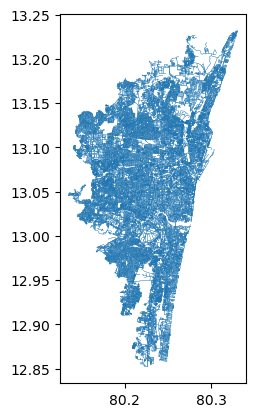

In [27]:
edges.plot(linewidth=0.2)

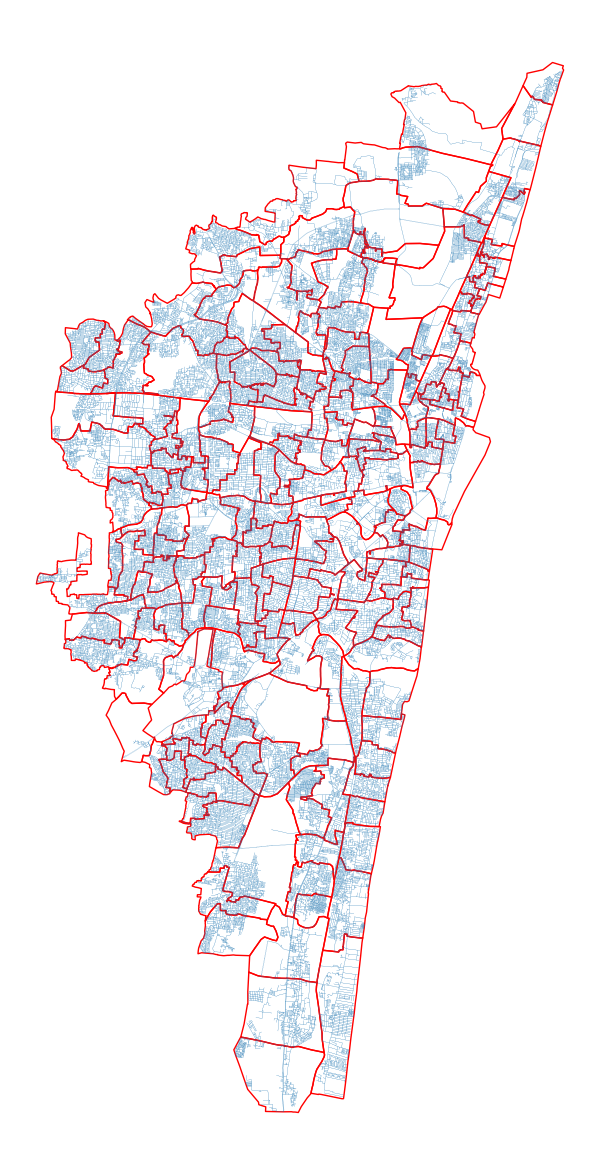

In [24]:
fig_path = IMAGES_DIR / 'road_network_chennai_with_wards_drive.png'
fig, ax = plt.subplots(1,1)
fig.set_size_inches(15,15)
edges.plot(linewidth = 0.1, ax = ax)
df.plot(ax = ax, facecolor="none", edgecolor="red")
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

## Statistics

Before proceeding, we need to reproject the file. In order to compute statistics etc., we cannot use files in latitude and longitude as a lot of computations are in metres. OSMNX has a built-in function to just convert this and projects this to the local UTM (which is UTM CRS 32643) for Bangalore. 

In [25]:
# https://github.com/gboeing/tec-workshop/blob/main/workshop1.ipynb
G_proj = ox.projection.project_graph(G)
print(f'The coordinate are now in {G_proj.graph["crs"]}')

The coordinate are now in EPSG:32644


In [26]:
stats = ox.basic_stats(G_proj)
stats

{'n': 69091,
 'm': 175297,
 'k_avg': 5.074380165289257,
 'edge_length_total': 12438273.385459015,
 'edge_length_avg': 70.95542642178141,
 'streets_per_node_avg': 2.6646885990939486,
 'streets_per_node_counts': {0: 0,
  1: 15552,
  2: 50,
  3: 45528,
  4: 7937,
  5: 22,
  6: 2},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.22509444066520964,
  2: 0.0007236832583115022,
  3: 0.6589570276881215,
  4: 0.11487748042436786,
  5: 0.000318420633657061,
  6: 2.8947330332460088e-05},
 'intersection_count': 53539,
 'street_length_total': 6695210.89434195,
 'street_segment_count': 91832,
 'street_length_avg': 72.90716628562974,
 'circuity_avg': 1.0424873313465395,
 'self_loop_proportion': 0.0005009147138252461}

In [27]:
print(f'The street length is {stats["street_length_total"]:.2f} metres or {stats["street_length_total"]/1000:.2f} km.') 

The street length is 6695210.89 metres or 6695.21 km.


Compute the area for Chennai:

In [28]:
## https://github.com/gboeing/osmnx-examples/blob/main/notebooks/
## 06-stats-indicators-centrality.ipynb
area = ox.projection.project_gdf(df).union_all().area
print(area)

431964790.9616235


In [29]:
print(f'The total area of Chennai is {area/1000000:.2f} km2')

The total area of Chennai is 431.96 km2


With the area as a parameter, you can obtain even more statistics:

In [30]:
stats_area = ox.basic_stats(G_proj, area=area)

In [31]:
stats_area

{'n': 69091,
 'm': 175297,
 'k_avg': 5.074380165289257,
 'edge_length_total': 12438273.385459015,
 'edge_length_avg': 70.95542642178141,
 'streets_per_node_avg': 2.6646885990939486,
 'streets_per_node_counts': {0: 0,
  1: 15552,
  2: 50,
  3: 45528,
  4: 7937,
  5: 22,
  6: 2},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.22509444066520964,
  2: 0.0007236832583115022,
  3: 0.6589570276881215,
  4: 0.11487748042436786,
  5: 0.000318420633657061,
  6: 2.8947330332460088e-05},
 'intersection_count': 53539,
 'street_length_total': 6695210.89434195,
 'street_segment_count': 91832,
 'street_length_avg': 72.90716628562974,
 'circuity_avg': 1.0424873313465395,
 'self_loop_proportion': 0.0005009147138252461,
 'node_density_km': 159.94590634619146,
 'intersection_density_km': 123.9429720205055,
 'edge_density_km': 28794.64633626599,
 'street_density_km': 15499.436607871045}

In [32]:
print(f'The street density is {stats_area["street_density_km"]:.2f} metres per km squared or {stats_area["street_density_km"]/1000:.2f} km per square kilometer.') 

The street density is 15499.44 metres per km squared or 15.50 km per square kilometer.


## References

Boeing, G. (2025).  Modeling and Analyzing Urban Networks and Amenities With OSMnx. Geographical Analysis 57, no. 4: 567577. https://doi.org/10.1111/gean.70009.

https://github.com/gboeing/osmnx-examples/tree/f6e821f598ccdb659999d008429cf867c69dcda1/notebooks
